# Class 1 - Data Cleaning

Yelp Restaurants Module 3 lab notebook. This notebook is organized for GitHub review and uses the final clean dataset produced by `scripts/run_pipeline.py`.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from yelp_lab.config import FINAL_SCHEMA

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "yelp_restaurants_clean.parquet"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "classes"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DISPLAY_DIR = PROJECT_ROOT / ".cache" / "notebook_figures"
NOTEBOOK_DISPLAY_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
_display_counter = 0

def show_and_close():
    global _display_counter
    for number in plt.get_fignums():
        _display_counter += 1
        fig = plt.figure(number)
        display_path = NOTEBOOK_DISPLAY_DIR / f"figure_{_display_counter:03d}.png"
        fig.savefig(display_path, dpi=160, bbox_inches="tight")
        display(Image(filename=str(display_path)))
    plt.close("all")

plt.show = show_and_close

print(df.shape)
df.head()

(5852, 22)


,business_id,state,city,latitude,longitude,dist_from_center,n_categories,price_range_num,has_wifi,has_parking,...,alcohol_num,noise_level_num,hours_open_per_week,n_days_open,review_count,log_review_count,review_velocity,mean_review_length,mean_review_sentiment_score,stars
0,MTSW4McQd7CbVtyjqoe9mw,PA,Philadelphia,39.955505,-75.155564,0.882586,5,1,1,1,...,0,0,94.0,7,80,4.394449,6.374473,558.919540,2.160920,4.0
1,MUTTqe8uqyMdBl186RmNeA,PA,Philadelphia,39.953949,-75.143226,1.879011,3,2,1,1,...,2,2,53.0,6,245,5.505332,60.471854,647.640000,3.772000,4.0
2,ROeacJQwBeh05Rqg7F6TCg,PA,Philadelphia,39.943223,-75.162568,1.066541,2,1,0,1,...,0,1,54.0,6,205,5.327876,25.700947,432.432692,2.533654,4.5
3,QdN72BWoyFypdGJhhI5r7g,PA,Philadelphia,39.939825,-75.157447,1.566801,5,2,1,1,...,2,2,78.0,7,65,4.189655,20.932101,514.275362,2.826087,4.0
4,Mjboz24M9NlBeiOJKLEd_Q,PA,Philadelphia,40.022466,-75.218314,8.990560,4,1,0,0,...,0,2,41.0,6,41,3.737670,7.779351,470.146341,1.000000,3.0


## Goal

Filter Yelp business data to restaurants in one city, understand the target, and save the first clean business table.

Original PDF tasks:
- Explore city, state, and star-rating distributions.
- Filter to restaurants in one city.
- Save `business_step1.parquet`.
- Make 3+ exploratory charts and 1 explanatory chart for Priya.

Note: raw Yelp JSON files are not committed to GitHub. The reproducible raw-to-final implementation lives in `src/yelp_lab/` and `scripts/run_pipeline.py`; this notebook uses the final clean parquet for reviewer-friendly evidence.

In [2]:
print("Rows:", len(df))
print("City:", df["city"].unique().tolist())
print("State:", df["state"].unique().tolist())
print("Columns:", len(df.columns))
df[["business_id", "city", "state", "stars", "review_count"]].head()

Rows: 5852
City: ['Philadelphia']
State: ['PA']
Columns: 22


,business_id,city,state,stars,review_count
0,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,4.0,80
1,MUTTqe8uqyMdBl186RmNeA,Philadelphia,PA,4.0,245
2,ROeacJQwBeh05Rqg7F6TCg,Philadelphia,PA,4.5,205
3,QdN72BWoyFypdGJhhI5r7g,Philadelphia,PA,4.0,65
4,Mjboz24M9NlBeiOJKLEd_Q,Philadelphia,PA,3.0,41


## Exploratory Chart 1 - Star Rating Distribution

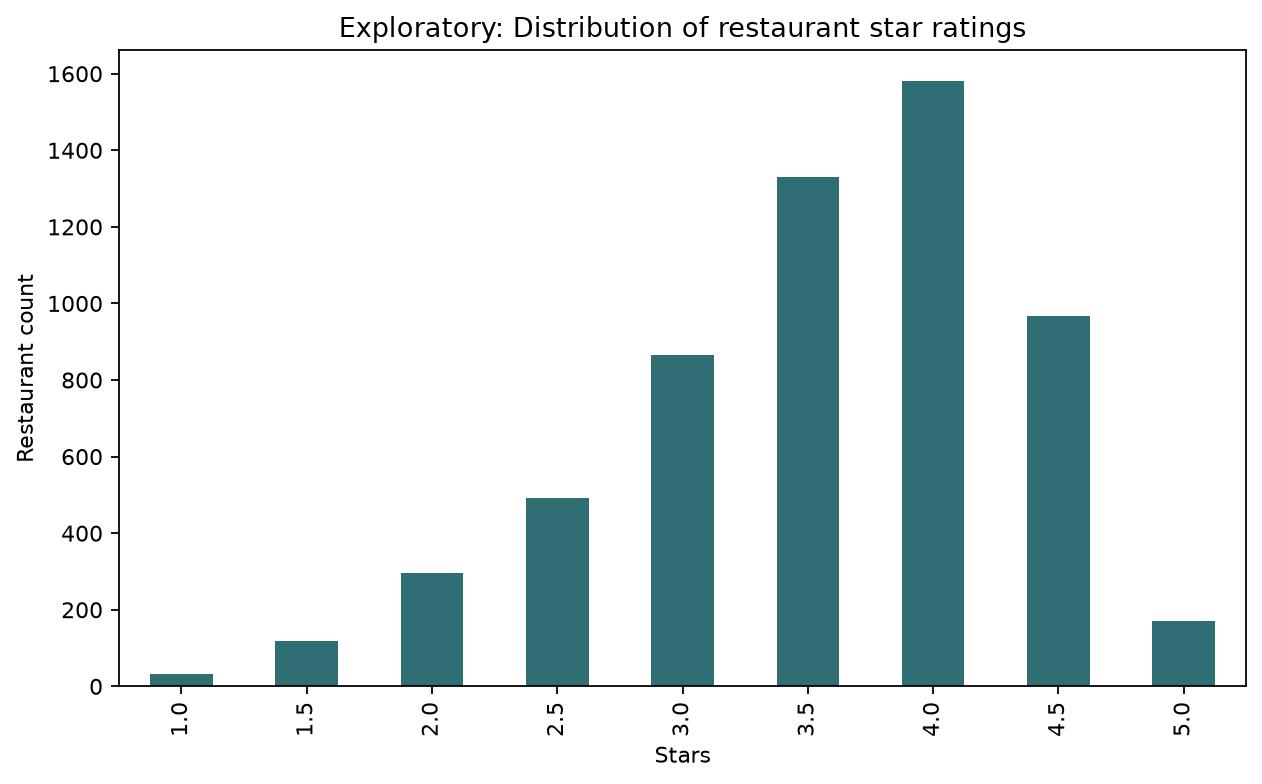

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
df["stars"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#2f6f73")
ax.set_title("Exploratory: Distribution of restaurant star ratings")
ax.set_xlabel("Stars")
ax.set_ylabel("Restaurant count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class1_exploratory_stars.png", dpi=160)
plt.show()

## Exploratory Chart 2 - Review Count Shape

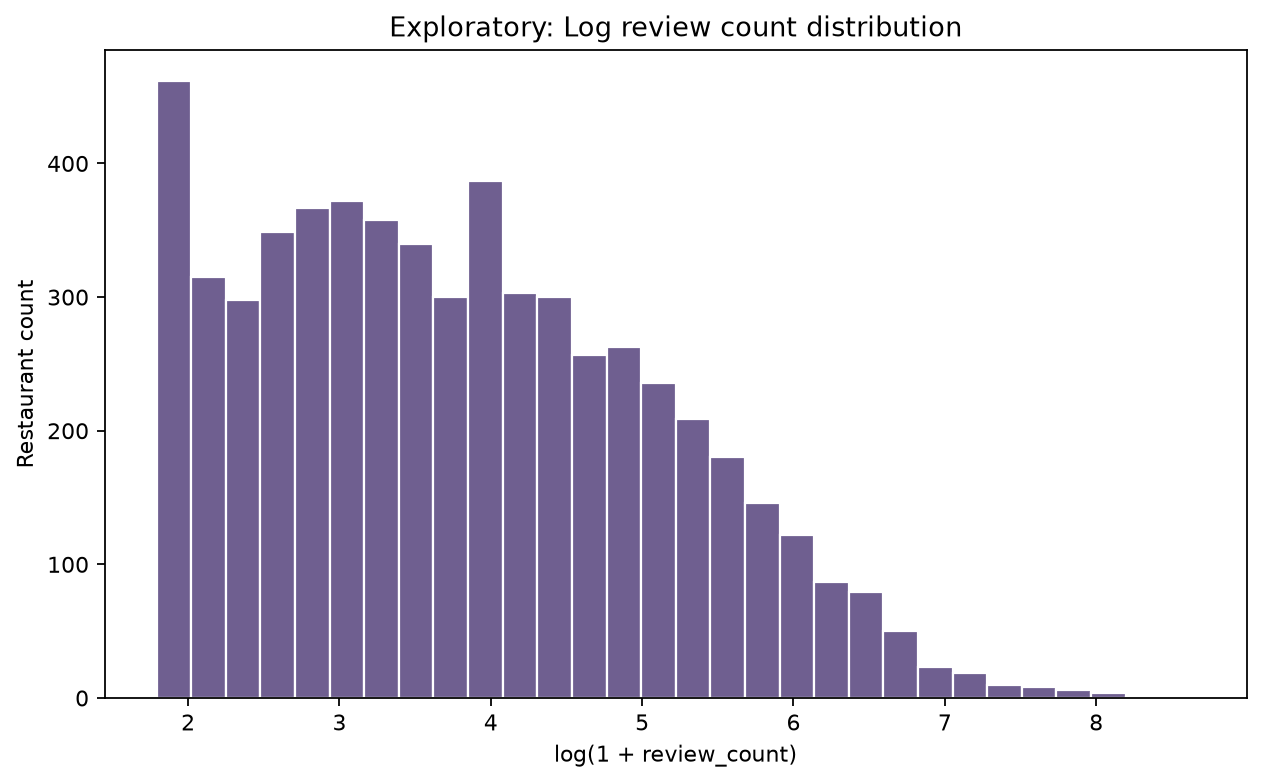

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["log_review_count"], bins=30, color="#6f5f90", edgecolor="white")
ax.set_title("Exploratory: Log review count distribution")
ax.set_xlabel("log(1 + review_count)")
ax.set_ylabel("Restaurant count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class1_exploratory_reviews.png", dpi=160)
plt.show()

## Exploratory Chart 3 - Restaurant Locations

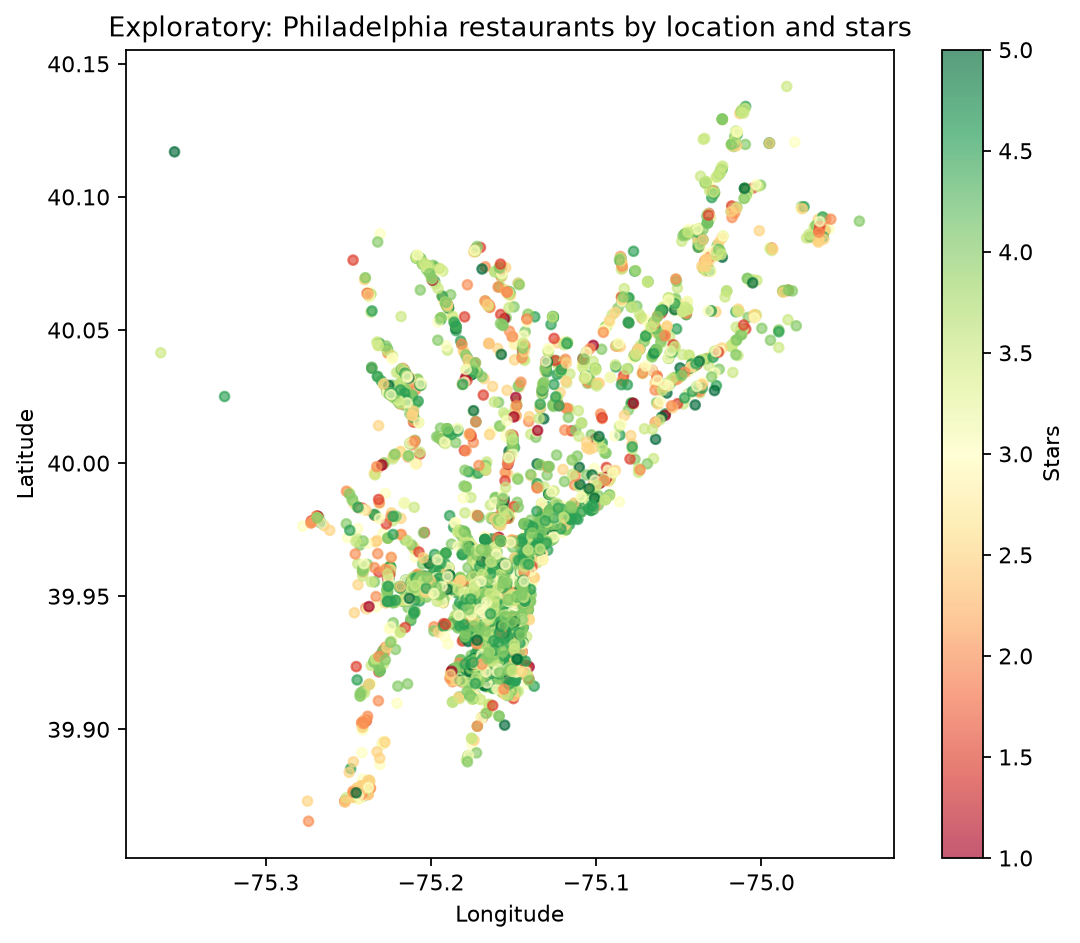

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(df["longitude"], df["latitude"], c=df["stars"], cmap="RdYlGn", alpha=0.65, s=18)
ax.set_title("Exploratory: Philadelphia restaurants by location and stars")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(scatter, ax=ax, label="Stars")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class1_exploratory_location.png", dpi=160)
plt.show()

## Explanatory Chart for Priya - Most Restaurants Cluster Around 3.5-4.0 Stars

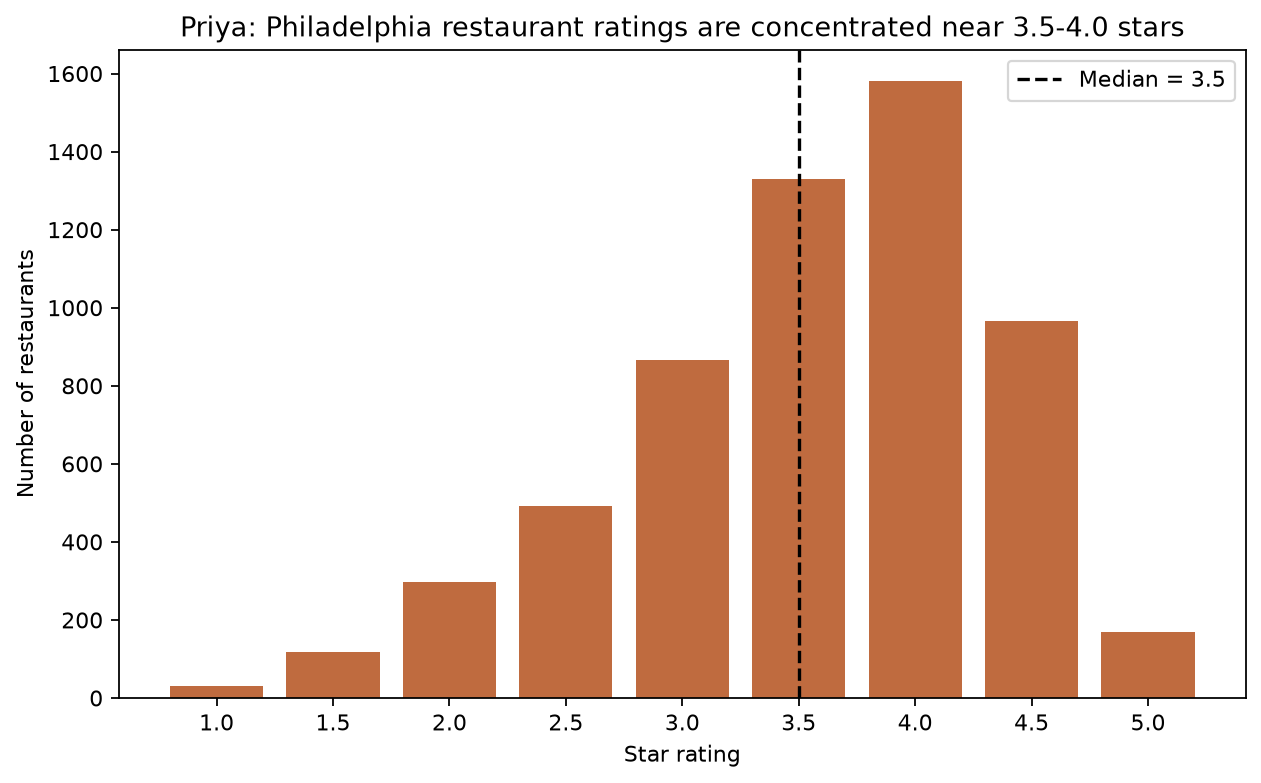

Takeaway: Most restaurants are not extreme; the target is centered near the middle-high range.


In [6]:
rating_summary = df.groupby("stars").size().rename("restaurant_count").reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(rating_summary["stars"].astype(str), rating_summary["restaurant_count"], color="#bf6b3f")
ax.axvline(str(df["stars"].median()), color="black", linestyle="--", label=f"Median = {df['stars'].median():.1f}")
ax.set_title("Priya: Philadelphia restaurant ratings are concentrated near 3.5-4.0 stars")
ax.set_xlabel("Star rating")
ax.set_ylabel("Number of restaurants")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class1_explanatory_rating_concentration.png", dpi=160)
plt.show()
print("Takeaway: Most restaurants are not extreme; the target is centered near the middle-high range.")

## Self-Check

- Final city is Philadelphia.
- Final row count is in the expected 5k-10k range.
- Star distribution has been inspected.
- Location and review-count patterns have been inspected.